# 8 部分因子试验设计

> **图 8.1**：不包含 $x_4$ 的式 (8.3) 中模型绝对系数的半正态图。

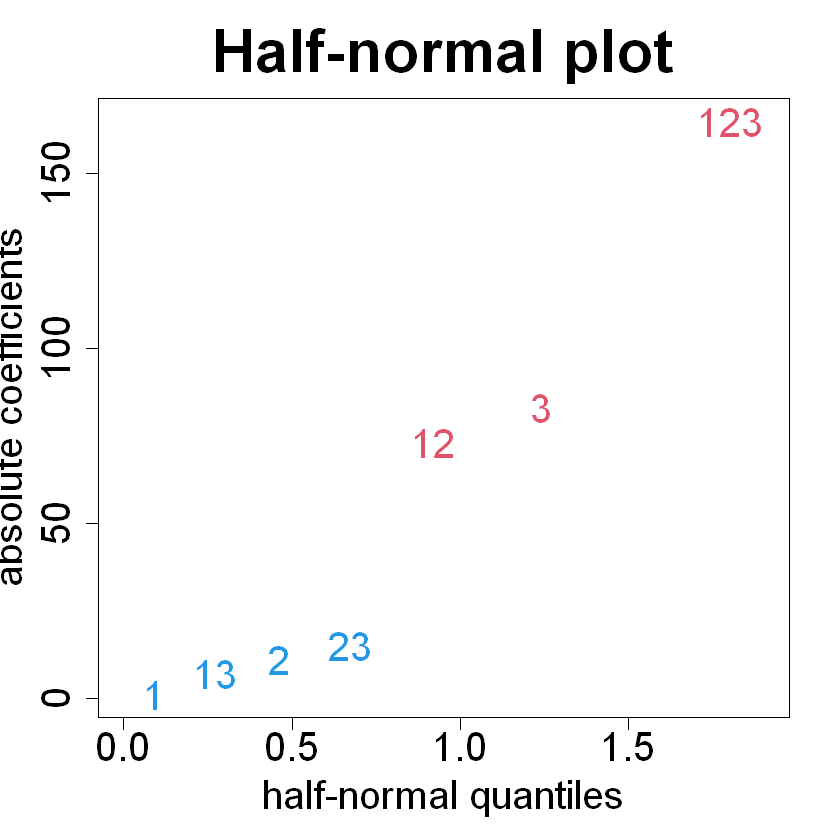

In [25]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/8.1-plot.RData")){
  A=rep(c(-1,1),c(4,4))
  B=rep(rep(c(-1,1),c(2,2)),2)
  C=rep(c(-1,1),4)
  D=A*B*C
  X=model.matrix(rep(1,8)~(A+B+C)^3)
  E=model.matrix(rep(1,8)~(A+B+C+D)^4)
  print(solve(t(X)%*%X)%*%t(X)%*%E)
  y=c(504,984,928,808,992,784,464,976)
  a=lm(y~(A+B+C)^3)
  print(summary(a))
  eff=a$coef[-1]
  names(eff)=c("1","2","3","12","13","23","123")
  save(eff,file="data/8.1-plot.RData")
}

load("data/8.1-plot.RData")
I=length(eff)
u=qnorm(.5+.5*(1:I-.5)/I)
saeff=sort(abs(eff))

options(repr.plot.width=7,repr.plot.height=7)
plot(u,saeff,type="n",xlab="half-normal quantiles",ylab="absolute coefficients",main="Half-normal plot",cex.main=3,cex.axis=2,cex.lab=2,xlim=c(0,max(u)+.1))
text(u,saeff,names(saeff),cex=2,col=c(rep(4,4),rep(2,3)))

> **图 8.2**：式 (8.9) 中系数绝对后验均值的半正态图。

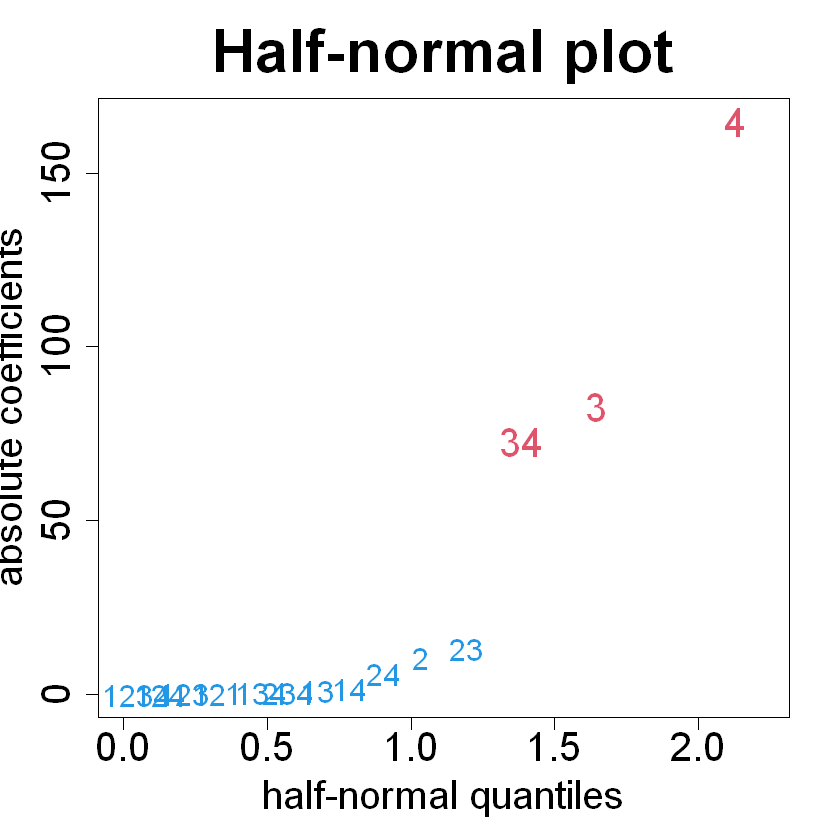

In [26]:
if(!dir.exists("data")) dir.create("data")
library(rkriging)

A=rep(c(-1,1),c(4,4))
B=rep(rep(c(-1,1),c(2,2)),2)
C=rep(c(-1,1),4)
D=A*B*C
d=cbind(A,B,C,D)
y=c(504,984,928,808,992,784,464,976)

if(!file.exists("data/8.2-plot.RData")){
  a=Fit.Kriging(d,y,kernel.parameters=list(type="Gaussian"))
  theta=Get.Kriging.Parameters(a)$lengthscale
  mu=Get.Kriging.Parameters(a)$mu
  gam=(1-exp(-2^2/(2*theta)))/(1+exp(-2^2/(2*theta)))
  X=model.matrix(lm(y~(A+B+C+D)^4),data=data.frame(A,B,C,D))
  G=diag(c(model.matrix(lm(1~(gam[1]+gam[2]+gam[3]+gam[4])^4))))
  alpha=G%*%t(X)%*%solve(X%*%G%*%t(X))%*%(y-mu)
  eff=alpha[-1]
  names(eff)=c("1","2","3","4","12","13","14","23","24","34","123","124","134","234","1234")
  save(eff,gam,file="data/8.2-plot.RData")
}

load("data/8.2-plot.RData")

I=length(eff)
u=qnorm(.5+.5*(1:I-.5)/I)
saeff=sort(abs(eff))
options(repr.plot.width=7,repr.plot.height=7)
plot(u,saeff,type="n",xlab="half-normal quantiles",ylab="absolute coefficients",main="Half-normal plot",cex.main=3,cex.axis=2,cex.lab=2,xlim=c(0,max(u)+.1))
size=c(rep(1.5,12),rep(2,3))
text(u,saeff,names(saeff),cex=size,col=c(rep(4,12),rep(2,3)))

> **图 8.3** 该密度图展示了 100 万组随机生成的 18 次试验设计对应的最大投影准则（左侧）与能量距离准则（右侧）。正交阵列 D1、D2、D3 的准则值分别以点竖线、虚竖线和实竖线表示。图中同时展示了对 D3 水平重排序后得到的各类不同准则数值。

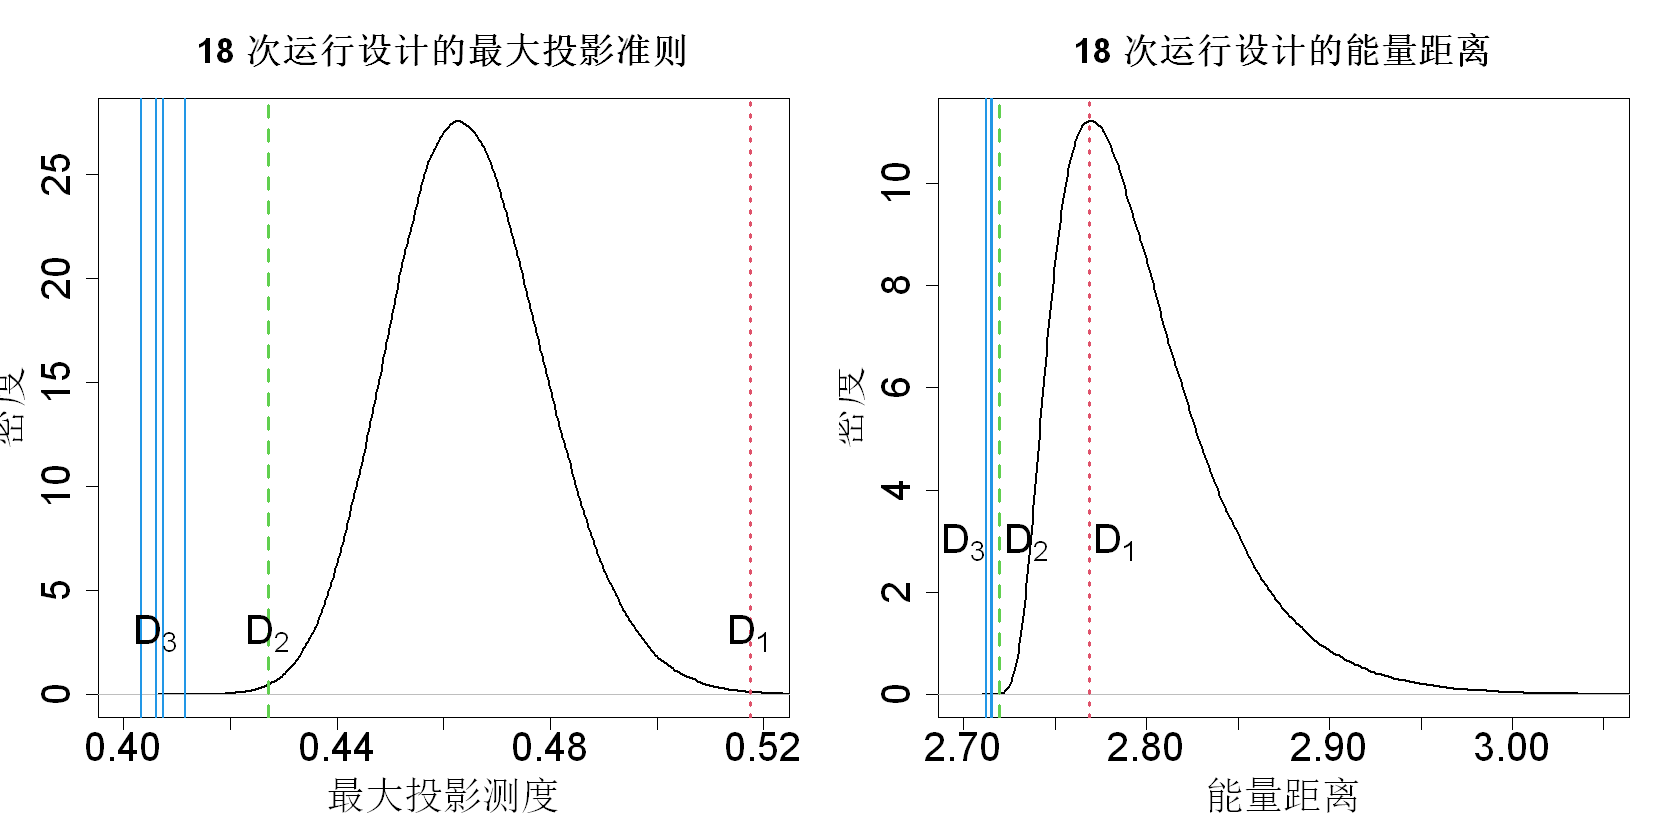

In [27]:
if(!dir.exists("data")) dir.create("data")
library(DoE.base)
library(SFDesign)
library(twinning)

full=full.factorial(4,3)
D=undesign(oa.design(nfactors=4,nlevels=3,randomize=FALSE))
D=data.matrix(D)
D1=rbind(D,D)
D1=(D1-1)/2
mp1=maxpro.crit(D1,delta=1/3^2)/3^2
en1=energy(full,D1)

#L18
D=undesign(oa.design(ID=L18,randomize=FALSE))
D=data.matrix(D)
D2=D[,2:5]
D2=(D2-1)/2
mp2=maxpro.crit(D2,delta=1/3^2)/3^2
en2=energy(full,D2)

D=undesign(oa.design(ID=L18,randomize=FALSE))
D=data.matrix(D)
D3=D[,3:6]
mp3=maxpro.crit((D3-1)/2,delta=1/3^2)/3^2
en3=energy(full,(D3-1)/2)

if(!file.exists("data/8.3-plot.RData")){
  A=array(data=rep(0,18*4*27),dim=c(18,4,27))
  D=undesign(oa.design(ID=L18,randomize=FALSE))
  D=data.matrix(D)
  D=D[,3:6]
  D1=(D[,1]-1)/2
  A1=lapply(1:3,function(i){
    D2=D[,2]
    if(i==2){
      D2=ifelse(D2==1,1,ifelse(D2==2,3,2))
    } else if(i==3){
      D2=ifelse(D2==1,2,ifelse(D2==2,1,3))
    }
    D2=(D2-1)/2
    return(D2)
  })

  A2=lapply(1:3,function(i){
    D3=D[,3]
    if(i==2){
      D3=ifelse(D3==1,1,ifelse(D3==2,3,2))
    } else if(i==3){
      D3=ifelse(D3==1,2,ifelse(D3==2,1,3))
    }
    D3=(D3-1)/2
    return(D3)
  })

  A3=lapply(1:3,function(i){
    D4=D[,4]
    if(i==2){
      D4=ifelse(D4==1,1,ifelse(D4==2,3,2))
    } else if(i==3){
      D4=ifelse(D4==1,2,ifelse(D4==2,1,3))
    }
    D4=(D4-1)/2
    return(D4)
  })

  a=expand.grid(c(1,2,3),c(1,2,3),c(1,2,3))
  for(i in 1:27){
    idx=a[i,]
    A[,,i]=cbind(D1,A1[[idx$Var1]],A2[[idx$Var2]],A3[[idx$Var3]])
  }

  val.mp=val.en=numeric(27)
  for(k in 1:27){
    val.mp[k]=maxpro.crit(A[,,k],delta=1/3^2)/3^2
    val.en[k]=energy(full,A[,,k])
  }
  N=1000000
  val.mp.sim=val.en.sim=numeric(N)
  for(i in 1:N){
    set.seed(i)
    D=full[sample(1:81,18),]
    val.mp.sim[i]=maxpro.crit(D,delta=1/3^2)/3^2
    val.en.sim[i]=energy(full,D)
  }
  save(val.mp,val.en,val.mp.sim,val.en.sim,file="data/8.3-plot.RData")
}
load("data/8.3-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(density(val.mp.sim),xlim=c(.4,.52),lwd=2,main="18 次运行设计的最大投影准则",xlab="最大投影测度",ylab="密度",cex.lab=2,cex.axis=2,cex.main=1.75)
abline(v=unique(val.mp),lwd=2,col=4)
abline(v=unique(mp1),lwd=3,lty=3,col=2)
abline(v=unique(mp2),lwd=3,lty=2,col=3)
text(mp1,3,expression(D[1]),cex=2)
text(mp2,3,expression(D[2]),cex=2)
text(mp3,3,expression(D[3]),cex=2)

plot(density(val.en.sim),xlim=c(2.7,3.05),lwd=2,main="18 次运行设计的能量距离",xlab="能量距离",ylab="密度",cex.lab=2,cex.axis=2,cex.main=1.75)
abline(v=unique(val.en),lwd=2,col=4)
abline(v=unique(en1),lwd=3,lty=3,col=2)
abline(v=unique(en2),lwd=3,lty=2,col=3)
text(en1+.015,3,expression(D[1]),cex=2)
text(en2+.015,3,expression(D[2]),cex=2)
text(en3-.015,3,expression(D[3]),cex=2)

> **图 8.4**：（左）两级单形格子设计；（右）两级单形重心设计。

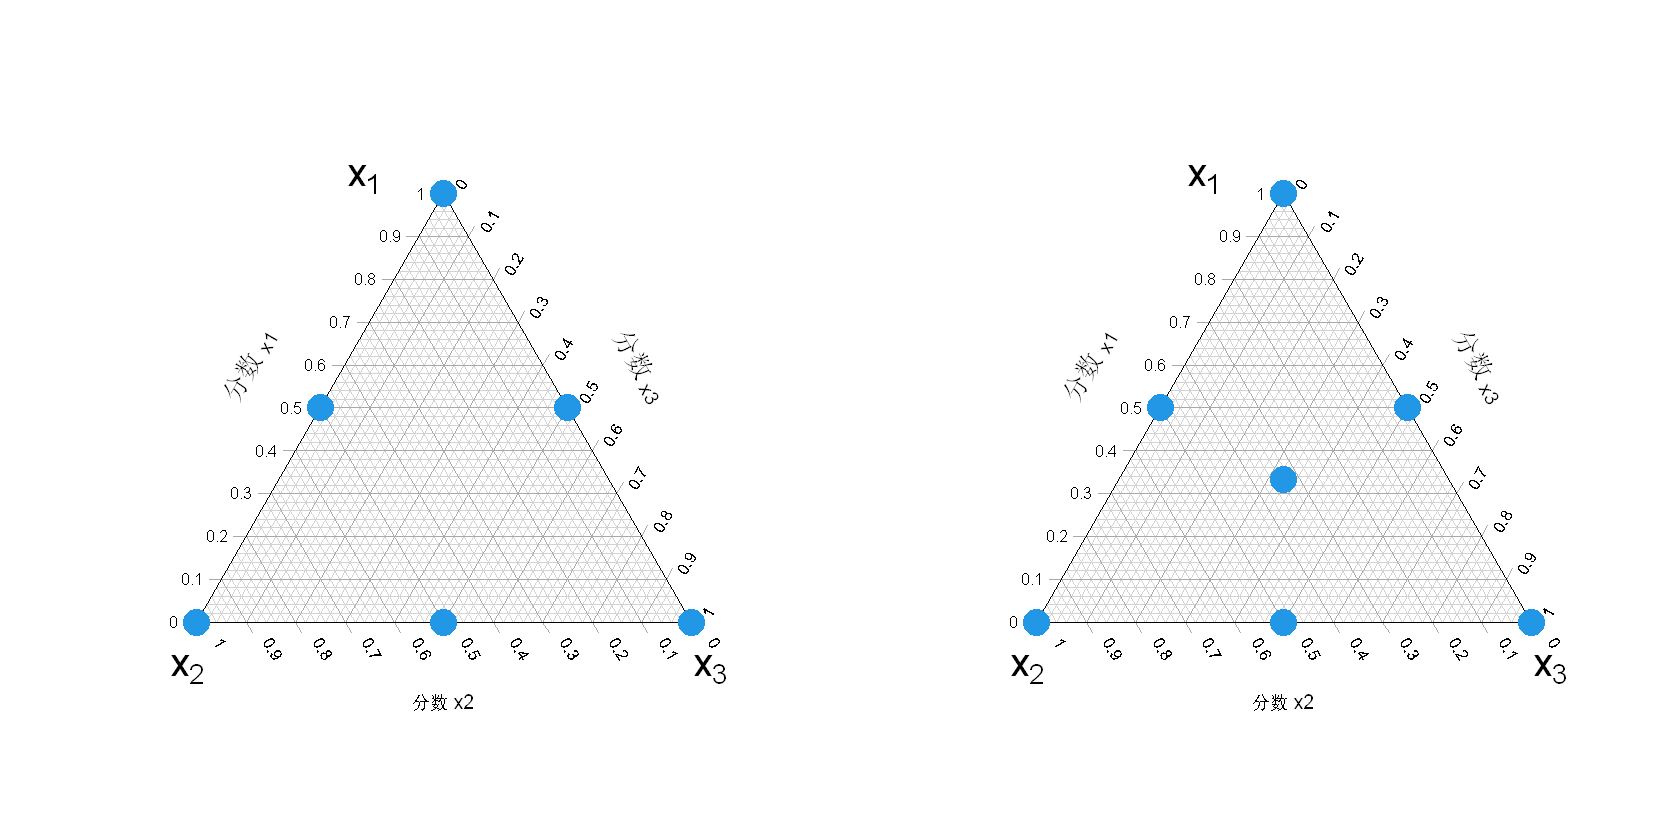

In [28]:
if(!dir.exists("data")) dir.create("data")
library(mixexp)
if(!file.exists("data/8.4-plot.RData")){
  D1=SLD(3,2)
  D2=SCD(3)
  save(D1,D2,file="data/8.4-plot.RData")
}

load("data/8.4-plot.RData")

library("Ternary")
options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
TernaryPlot(axis.labels=seq(0,1,by=0.1),atip=expression(x[1]),btip=expression(x[3]),ctip=expression(x[2]),alab="分数 x1",blab="分数 x3",clab="分数 x2",lab.cex=1,tip.cex=2)
TernaryPoints(D1,cex=3,col=4,pch=16)
TernaryPlot(axis.labels=seq(0,1,by=0.1),atip=expression(x[1]),btip=expression(x[3]),ctip=expression(x[2]),alab="分数 x1",blab="分数 x3",clab="分数 x2",lab.cex=1,tip.cex=2)
TernaryPoints(D2,cex=3,col=4,pch=16)

> **图 8.5**：单纯形中无任何附加约束（左侧）与存在约束（右侧）条件下的 11 个支撑点。

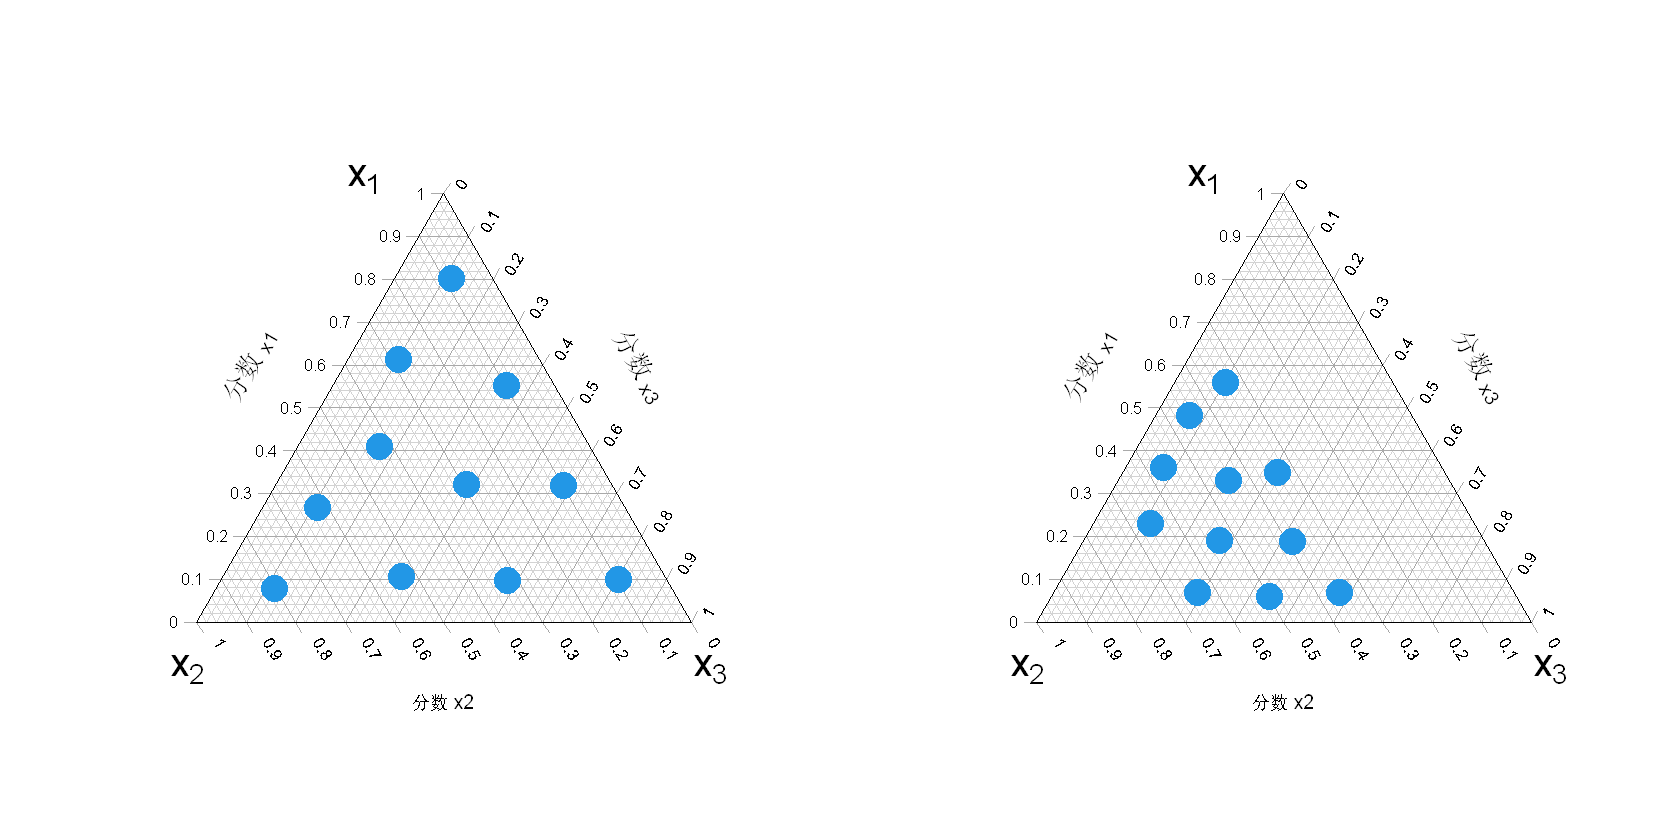

In [29]:
if(!dir.exists("data")) dir.create("data")
library(spacefillr)
library(support)
library(Ternary)
p=3
N=10000
u=generate_sobol_set(N,p-1)
x=matrix(0,nrow=N,ncol=p)
x[,1]=(1-u[,1]^(1/2))
x[,2]=u[,1]^(1/2)*(1-u[,2])
x[,3]=u[,1]^(1/2)*u[,2]
set.seed(1)
n=11
if(!file.exists("data/8.5-plot1.RData")){
  D1=sp(n,p,dist.samp=x)$sp
  save(D1,file="data/8.5-plot1.RData")
}
load("data/8.5-plot1.RData")
options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
TernaryPlot(axis.labels=seq(0,1,by=0.1),atip=expression(x[1]),btip=expression(x[3]),ctip=expression(x[2]),alab="分数 x1",blab="分数 x3",clab="分数 x2",lab.cex=1,tip.cex=2)
TernaryPoints(D1,cex=3,col=4,pch=16)
CAND=x
C1=(x[,1]+x[,2]<.7)
C2=(x[,1]+x[,2]>.3)
CAND=CAND[C1&C2,]
if(!file.exists("data/8.5-plot2.RData")){
  D2=sp(n,p,dist.samp=CAND)$sp
  save(D2,file="data/8.5-plot2.RData")
}
load("data/8.5-plot2.RData")
TernaryPlot(axis.labels=seq(0,1,by=0.1),atip=expression(x[1]),btip=expression(x[3]),ctip=expression(x[2]),alab="分数 x1",blab="分数 x3",clab="分数 x2",lab.cex=1,tip.cex=2)
TernaryPoints(D2,cex=3,col=4,pch=16)